In [1]:
import argparse
import tracemalloc
import time
import gc
import os
from dataclasses import dataclass
from typing import Iterable, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

In [2]:
@dataclass
class BinaryMnistData:
    train_x: Tensor
    train_y: Tensor
    test_x: Tensor
    test_y: Tensor


class LogisticRegression(nn.Module):
    """A single linear layer is logistic regression for binary classification."""

    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        return self.linear(x).squeeze(-1)

def parse_args(argv=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="PyTorch influence function demo for binary MNIST logistic regression."
    )
    parser.add_argument("--data-dir", default="data", help="Directory for MNIST data.")
    parser.add_argument("--output-dir", default="outputs", help="Directory for saved results.")
    parser.add_argument("--digit-a", type=int, default=0, help="Negative class digit.")
    parser.add_argument("--digit-b", type=int, default=1, help="Positive class digit.")
    parser.add_argument("--train-size", type=int, default=1000, help="Number of train examples.")
    parser.add_argument("--test-size", type=int, default=200, help="Number of test examples.")
    parser.add_argument("--test-index", type=int, default=0, help="Test example to explain.")
    parser.add_argument("--top-k", type=int, default=5, help="How many helpful/harmful examples to print.")
    parser.add_argument("--epochs", type=int, default=200, help="Training epochs.")
    parser.add_argument("--lr", type=float, default=0.5, help="Learning rate.")
    parser.add_argument("--batch-size", type=int, default=256, help="Training batch size.")
    parser.add_argument("--weight-decay", type=float, default=1e-3, help="L2 regularization strength.")
    parser.add_argument("--damping", type=float, default=1e-4, help="Extra Hessian damping.")
    parser.add_argument("--sanity-checks", type=int, default=3, help="Actual LOO retrains to compare.")
    parser.add_argument("--seed", type=int, default=0, help="Random seed.")
    return parser.parse_args(argv)

def resolve_script_path(path: str) -> str:
    """Resolve relative paths in both script and notebook environments."""
    if os.path.isabs(path):
        return path
    base_dir = os.path.dirname(__file__) if "__file__" in globals() else os.getcwd()
    return os.path.join(base_dir, path)

def load_binary_mnist(args: argparse.Namespace, device: torch.device) -> BinaryMnistData:
    transform = transforms.ToTensor()
    data_dir = resolve_script_path(args.data_dir)

    train_set = datasets.MNIST(data_dir, train=True, download=True, transform=transform)
    test_set = datasets.MNIST(data_dir, train=False, download=True, transform=transform)

    def filter_digits(dataset: datasets.MNIST, limit: int) -> Tuple[Tensor, Tensor]:
        xs = dataset.data.float().div(255.0).view(-1, 28 * 28)
        labels = dataset.targets
        mask = (labels == args.digit_a) | (labels == args.digit_b)
        xs = xs[mask]
        labels = labels[mask]
        ys = (labels == args.digit_b).float()
        return xs[:limit].to(device), ys[:limit].to(device)

    train_x, train_y = filter_digits(train_set, args.train_size)
    test_x, test_y = filter_digits(test_set, args.test_size)
    return BinaryMnistData(train_x=train_x, train_y=train_y, test_x=test_x, test_y=test_y)

def train_model(
    train_x: Tensor,
    train_y: Tensor,
    args: argparse.Namespace,
    device: torch.device,
) -> LogisticRegression:
    torch.manual_seed(args.seed)
    model = LogisticRegression(train_x.shape[1]).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
    loader = DataLoader(
        TensorDataset(train_x, train_y),
        batch_size=args.batch_size,
        shuffle=True,
    )

    for _ in range(args.epochs):
        for batch_x, batch_y in loader:
            logits = model(batch_x)
            data_loss = F.binary_cross_entropy_with_logits(logits, batch_y)
            # The Hessian below uses the same L2 term: (lambda / 2) * ||w||^2.
            reg_loss = 0.5 * args.weight_decay * model.linear.weight.pow(2).sum()
            loss = data_loss + reg_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model


def evaluate(model: LogisticRegression, x: Tensor, y: Tensor) -> Tuple[float, float]:
    with torch.no_grad():
        logits = model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y).item()
        preds = (torch.sigmoid(logits) >= 0.5).float()
        acc = (preds == y).float().mean().item()
    return loss, acc


def per_example_weight_grads(model: LogisticRegression, x: Tensor, y: Tensor) -> Tensor:
    """Per-example gradients of unregularized BCE loss from PyTorch autograd."""
    grads = []
    weight = model.linear.weight

    for i in range(x.shape[0]):
        # Autograd computes d loss_i / d weight; no closed-form gradient is used here.
        logit = model(x[i : i + 1])
        loss = F.binary_cross_entropy_with_logits(logit, y[i : i + 1], reduction="sum")
        grad = torch.autograd.grad(loss, weight, retain_graph=False, create_graph=False)[0]
        grads.append(grad.reshape(-1).detach())

    return torch.stack(grads, dim=0)


def logistic_hessian(
    model: LogisticRegression,
    x: Tensor,
    y: Tensor,
    weight_decay: float,
    damping: float,
) -> Tensor:
    """Hessian of mean BCE + L2 regularization from PyTorch autograd."""
    weight = model.linear.weight.detach().reshape(-1).requires_grad_(True)

    def objective(flat_weight: Tensor) -> Tensor:
        # Autograd computes the second derivative; no closed-form Hessian is used here.
        logits = x.matmul(flat_weight)
        data_loss = F.binary_cross_entropy_with_logits(logits, y, reduction="mean")
        reg_loss = 0.5 * weight_decay * flat_weight.dot(flat_weight)
        return data_loss + reg_loss

    hessian = torch.autograd.functional.hessian(objective, weight, vectorize=True)
    eye = torch.eye(hessian.shape[0], device=x.device, dtype=x.dtype)
    return hessian.detach() + damping * eye




def tensor_memory_mb(*tensors: Tensor) -> float:
    """Approximate memory used by the given tensors in MB."""
    total_bytes = 0
    for tensor in tensors:
        if tensor is not None:
            total_bytes += tensor.numel() * tensor.element_size()
    return total_bytes / (1024 ** 2)


def current_rss_mb():
    """Best-effort resident memory measurement for notebook benchmarking."""
    try:
        import psutil

        return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    except Exception:
        return None


def hessian_vector_product_autograd(
    model: LogisticRegression,
    x: Tensor, # upweighting sample
    y: Tensor,
    vector: Tensor,
    weight_decay: float,
    damping: float,
) -> Tensor:
    """Compute (H + damping I) v with double backprop, like hessians.py HVP."""
    flat_weight = model.linear.weight.detach().reshape(-1).requires_grad_(True)
    vector = vector.detach()

    logits = x.matmul(flat_weight)
    data_loss = F.binary_cross_entropy_with_logits(logits, y, reduction="mean")
    reg_loss = 0.5 * weight_decay * flat_weight.dot(flat_weight)
    loss = data_loss + reg_loss

    grad = torch.autograd.grad(loss, flat_weight, create_graph=True)[0]
    hvp = torch.autograd.grad(grad.dot(vector), flat_weight, retain_graph=False)[0]
    return hvp.detach() + damping * vector


def inverse_hvp_naive_hessian(
    model: LogisticRegression,
    x: Tensor,
    y: Tensor,
    vector: Tensor,
    weight_decay: float,
    damping: float,
) -> Tuple[Tensor, dict]:
    """Build the full Hessian explicitly, then solve Hx=v."""
    hessian = logistic_hessian(model, x, y, weight_decay, damping)
    inverse_hvp = torch.linalg.solve(hessian, vector)
    info = {
        "tensor_est_mb": tensor_memory_mb(hessian, inverse_hvp),
        "iterations": 1,
        "residual": float(torch.linalg.norm(hessian.matmul(inverse_hvp) - vector).detach().cpu()),
    }
    return inverse_hvp.detach(), info


def inverse_hvp_cg(
    model: LogisticRegression,
    x: Tensor,
    y: Tensor,
    vector: Tensor,
    weight_decay: float,
    damping: float,
    max_iter: int = 50,
    tol: float = 1e-6,
) -> Tuple[Tensor, dict]:
    """Conjugate gradient solve for Hx=v using only autograd HVPs."""
    solution = torch.zeros_like(vector)
    residual = vector.clone()
    direction = residual.clone()
    residual_sq = residual.dot(residual)
    initial_norm = torch.sqrt(residual_sq).clamp_min(1e-12)

    last_iter = 0
    for last_iter in range(1, max_iter + 1):
        h_direction = hessian_vector_product_autograd(
            model, x, y, direction, weight_decay, damping
        )
        alpha = residual_sq / direction.dot(h_direction).clamp_min(1e-12)
        solution = solution + alpha * direction
        residual = residual - alpha * h_direction
        new_residual_sq = residual.dot(residual)
        rel_residual = torch.sqrt(new_residual_sq) / initial_norm
        if rel_residual.item() < tol:
            residual_sq = new_residual_sq
            break
        beta = new_residual_sq / residual_sq.clamp_min(1e-12)
        direction = residual + beta * direction
        residual_sq = new_residual_sq

    info = {
        "tensor_est_mb": tensor_memory_mb(solution, residual, direction),
        "iterations": last_iter,
        "residual": float(torch.sqrt(residual_sq).detach().cpu()),
    }
    return solution.detach(), info


def inverse_hvp_lissa(
    model: LogisticRegression,
    x: Tensor,
    y: Tensor,
    vector: Tensor,
    weight_decay: float,
    damping: float,
    batch_size: int = 100,
    recursion_depth: int = 300,
    scale: float = 10.0,
    num_samples: int = 1,
) -> Tuple[Tensor, dict]:
    """Mini-batch LiSSA recursion for approximating H^{-1}v."""
    n = x.shape[0]
    estimates = []

    for _ in range(num_samples):
        cur_estimate = vector.clone()
        for _ in range(recursion_depth):
            batch_indices = torch.randint(0, n, (batch_size,), device=x.device)
            hvp = hessian_vector_product_autograd(
                model,
                x[batch_indices],
                y[batch_indices],
                cur_estimate,
                weight_decay,
                damping,
            )
            # This is the Neumann-series style update used by LiSSA.
            cur_estimate = vector + cur_estimate - hvp / scale
        estimates.append(cur_estimate / scale)

    inverse_hvp = torch.stack(estimates, dim=0).mean(dim=0)
    full_residual = hessian_vector_product_autograd(
        model, x, y, inverse_hvp, weight_decay, damping
    ) - vector
    info = {
        "tensor_est_mb": tensor_memory_mb(inverse_hvp, cur_estimate),
        "iterations": recursion_depth * num_samples,
        "residual": float(torch.linalg.norm(full_residual).detach().cpu()),
    }
    return inverse_hvp.detach(), info


def benchmark_inverse_hvp(method_name: str, fn, device: torch.device):
    """Measure wall time and best-effort memory while computing one inverse-HVP."""
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    rss_before = current_rss_mb()
    tracemalloc.start()
    start = time.perf_counter()
    inverse_hvp, info = fn()
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elapsed = time.perf_counter() - start
    _, python_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after = current_rss_mb()

    row = {
        "method": method_name,
        "time_sec": elapsed,
        "python_peak_mb": python_peak / (1024 ** 2),
        "rss_delta_mb": None if rss_before is None or rss_after is None else rss_after - rss_before,
        "cuda_peak_mb": 0.0
        if device.type != "cuda"
        else torch.cuda.max_memory_allocated(device) / (1024 ** 2),
    }
    row.update(info)
    return inverse_hvp, row


def print_benchmark_table(rows):
    print("\nInverse-HVP benchmark")
    print(" method        | time(s) | tensor_est(MB) | py_peak(MB) | rss_delta(MB) | cuda_peak(MB) | iters | residual")
    print("---------------+---------+----------------+-------------+---------------+---------------+-------+----------")
    for row in rows:
        rss = "n/a" if row["rss_delta_mb"] is None else f"{row['rss_delta_mb']:.2f}"
        print(
            f" {row['method']:<13} | {row['time_sec']:>7.3f} | "
            f"{row['tensor_est_mb']:>14.2f} | {row['python_peak_mb']:>11.2f} | "
            f"{rss:>13} | {row['cuda_peak_mb']:>13.2f} | "
            f"{row['iterations']:>5} | {row['residual']:.2e}"
        )

def upweight_effect(train_grad: Tensor, inverse_hvp: Tensor) -> Tensor:
    """Effect on test loss if each training point receives infinitesimal upweight.

    d loss_test / d epsilon_i = - grad_test^T H^{-1} grad_train_i.
    Negative means upweighting this training point would reduce the test loss.
    """
    return -train_grad.matmul(inverse_hvp)


def leave_one_out_approx(upweight_scores: Tensor, num_train: int) -> Tensor:
    """Approximate test-loss change after removing each training point.

    Removing one point is approximately the same as upweighting it by -1 / n.
    """
    return -upweight_scores / num_train


def helpful_harmful_indices(loo_scores: Tensor, top_k: int) -> Tuple[Tensor, Tensor]:
    """Helpful examples hurt the test point when removed; harmful examples help when removed."""
    helpful = torch.argsort(loo_scores, descending=True)[:top_k]
    harmful = torch.argsort(loo_scores, descending=False)[:top_k]
    return helpful, harmful


def print_examples(title: str, indices: Iterable[int], data: BinaryMnistData, up_scores: Tensor, loo_scores: Tensor) -> None:
    print(f"\n{title}")
    print(" rank | train_idx | label | upweight_effect | loo_loss_delta")
    print("------+-----------+-------+-----------------+---------------")
    for rank, idx_tensor in enumerate(indices, start=1):
        idx = int(idx_tensor)
        label = int(data.train_y[idx].item())
        print(
            f" {rank:>4} | {idx:>9} | {label:>5} | "
            f"{up_scores[idx].item():>15.8f} | {loo_scores[idx].item():>13.8f}"
        )


def retrain_without_one(
    data: BinaryMnistData,
    remove_idx: int,
    test_idx: int,
    args: argparse.Namespace,
    device: torch.device,
) -> float:
    keep_mask = torch.ones(data.train_x.shape[0], dtype=torch.bool, device=device)
    keep_mask[remove_idx] = False
    model = train_model(data.train_x[keep_mask], data.train_y[keep_mask], args, device)
    with torch.no_grad():
        test_logit = model(data.test_x[test_idx : test_idx + 1])
        test_loss = F.binary_cross_entropy_with_logits(test_logit, data.test_y[test_idx : test_idx + 1])
    return test_loss.item()


def sanity_check_retraining(
    data: BinaryMnistData,
    baseline_test_loss: float,
    loo_scores: Tensor,
    candidate_indices: Tensor,
    args: argparse.Namespace,
    device: torch.device,
) -> None:
    if args.sanity_checks <= 0:
        return

    print("\nLeave-one-out sanity check")
    print(" train_idx | approx_delta | actual_delta")
    print("-----------+--------------+-------------")
    for idx_tensor in candidate_indices[: args.sanity_checks]:
        idx = int(idx_tensor)
        actual_loss = retrain_without_one(data, idx, args.test_index, args, device)
        actual_delta = actual_loss - baseline_test_loss
        print(f" {idx:>9} | {loo_scores[idx].item():>12.8f} | {actual_delta:>11.8f}")

In [17]:
# Notebook runner: this replaces command-line main().
# Run the definition cells above first, then run this cell.

from pathlib import Path

# Make relative data/output paths land inside influence-release/test.
notebook_dir = Path.cwd()
if not (notebook_dir / "influence_binary_mnist_pytorch.py").exists():
    candidate = notebook_dir / "influence-release" / "test"
    if candidate.exists():
        os.chdir(candidate)

args = parse_args([])  # Important in notebooks: ignore Jupyter's own -f kernel argument.

# You can edit these values interactively.
args.train_size = 1000
args.test_size = 200
args.test_index = 30
args.top_k = 10
args.epochs = 200
args.sanity_checks = 20
args.data_dir = "data"
args.output_dir = "outputs"

torch.manual_seed(args.seed)
np.random.seed(args.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = load_binary_mnist(args, device)
if args.test_index >= data.test_x.shape[0]:
    raise ValueError(f"--test-index must be less than {data.test_x.shape[0]}")

model = train_model(data.train_x, data.train_y, args, device)
train_loss, train_acc = evaluate(model, data.train_x, data.train_y)
test_loss, test_acc = evaluate(model, data.test_x, data.test_y)
print(f"Device: {device}")
print(f"Binary MNIST: {args.digit_a} vs {args.digit_b}")
print(f"Train size: {data.train_x.shape[0]}, test size: {data.test_x.shape[0]}")
print(f"Train loss/acc: {train_loss:.6f} / {train_acc:.4f}")
print(f"Test loss/acc : {test_loss:.6f} / {test_acc:.4f}")

test_x = data.test_x[args.test_index : args.test_index + 1]
test_y = data.test_y[args.test_index : args.test_index + 1]
with torch.no_grad():
    baseline_test_loss = F.binary_cross_entropy_with_logits(model(test_x), test_y).item()
print(
    f"\nExplaining test index {args.test_index} "
    f"(label={int(test_y.item())}, loss={baseline_test_loss:.6f})"
)

train_grads = per_example_weight_grads(model, data.train_x, data.train_y)
test_grad = per_example_weight_grads(model, test_x, test_y).squeeze(0)

# Tune these for speed vs quality. LiSSA is intentionally mini-batch and approximate.
cg_max_iter = 50
cg_tol = 1e-6
lissa_batch_size = min(300, data.train_x.shape[0])
lissa_depth = 100
lissa_scale = 5.0
lissa_num_samples = 1

inverse_hvp_results = {}
benchmark_rows = []

inverse_hvp_results["naive_hessian"], row = benchmark_inverse_hvp(
    "naive_hessian",
    lambda: inverse_hvp_naive_hessian(
        model, data.train_x, data.train_y, test_grad, args.weight_decay, args.damping
    ),
    device,
)
benchmark_rows.append(row)

inverse_hvp_results["lissa_minibatch"], row = benchmark_inverse_hvp(
    "lissa_minibatch",
    lambda: inverse_hvp_lissa(
        model,
        data.train_x,
        data.train_y,
        test_grad,
        args.weight_decay,
        args.damping,
        batch_size=lissa_batch_size,
        recursion_depth=lissa_depth,
        scale=lissa_scale,
        num_samples=lissa_num_samples,
    ),
    device,
)
benchmark_rows.append(row)

inverse_hvp_results["cg"], row = benchmark_inverse_hvp(
    "cg",
    lambda: inverse_hvp_cg(
        model,
        data.train_x,
        data.train_y,
        test_grad,
        args.weight_decay,
        args.damping,
        max_iter=cg_max_iter,
        tol=cg_tol,
    ),
    device,
)
benchmark_rows.append(row)

print_benchmark_table(benchmark_rows)

influence_results = {}
for method_name, inverse_hvp in inverse_hvp_results.items():
    cur_up_scores = upweight_effect(train_grads, inverse_hvp)
    cur_loo_scores = leave_one_out_approx(cur_up_scores, data.train_x.shape[0])
    cur_helpful, cur_harmful = helpful_harmful_indices(cur_loo_scores, args.top_k)
    influence_results[method_name] = {
        "inverse_hvp": inverse_hvp,
        "up_scores": cur_up_scores,
        "loo_scores": cur_loo_scores,
        "helpful": cur_helpful,
        "harmful": cur_harmful,
    }

    print_examples(f"[{method_name}] Most helpful training examples", cur_helpful, data, cur_up_scores, cur_loo_scores)
    print_examples(f"[{method_name}] Most harmful training examples", cur_harmful, data, cur_up_scores, cur_loo_scores)

Device: cuda
Binary MNIST: 0 vs 1
Train size: 1000, test size: 200
Train loss/acc: 0.002315 / 1.0000
Test loss/acc : 0.002900 / 1.0000

Explaining test index 30 (label=0, loss=0.000410)

Inverse-HVP benchmark
 method        | time(s) | tensor_est(MB) | py_peak(MB) | rss_delta(MB) | cuda_peak(MB) | iters | residual
---------------+---------+----------------+-------------+---------------+---------------+-------+----------
 naive_hessian |   0.005 |           2.35 |        0.01 |          0.00 |         33.71 |     1 | 1.07e-09
 lissa_minibatch |   0.089 |           0.01 |        0.03 |          0.00 |         24.61 |   100 | 2.76e-03
 cg            |   0.054 |           0.01 |        0.02 |          0.00 |         23.73 |    50 | 8.81e-07

[naive_hessian] Most helpful training examples
 rank | train_idx | label | upweight_effect | loo_loss_delta
------+-----------+-------+-----------------+---------------
    1 |        53 |     0 |     -0.04608586 |    0.00004609
    2 |       879 |    

In [19]:
# Keep these variable names for the visualization cell below.
selected_method = "naive_hessian"
inverse_hvp = influence_results[selected_method]["inverse_hvp"]
up_scores = influence_results[selected_method]["up_scores"]
loo_scores = influence_results[selected_method]["loo_scores"]
helpful = influence_results[selected_method]["helpful"]
harmful = influence_results[selected_method]["harmful"]

sanity_candidates = torch.cat([helpful, harmful])
sanity_check_retraining(data, baseline_test_loss, loo_scores, sanity_candidates, args, device)

output_dir = resolve_script_path(args.output_dir)
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "binary_mnist_influence_results.npz")
np.savez(
    output_path,
    benchmark=np.array(benchmark_rows, dtype=object),
    selected_method=selected_method,
    upweight_effect=up_scores.detach().cpu().numpy(),
    leave_one_out_delta=loo_scores.detach().cpu().numpy(),
    helpful_indices=helpful.detach().cpu().numpy(),
    harmful_indices=harmful.detach().cpu().numpy(),
    test_index=args.test_index,
    digit_a=args.digit_a,
    digit_b=args.digit_b,
)
print(f"\nSaved results to {output_path}")



Leave-one-out sanity check
 train_idx | approx_delta | actual_delta
-----------+--------------+-------------
        53 |   0.00004609 |  0.00004482
       879 |   0.00004471 |  0.00006866
       799 |   0.00002233 |  0.00003481
       291 |   0.00002017 |  0.00003529
       253 |   0.00001949 |  0.00002956
       249 |   0.00001466 |  0.00003719
       469 |   0.00001276 |  0.00001764
       500 |   0.00001250 |  0.00001383
       330 |   0.00001167 |  0.00002193
       858 |   0.00001072 |  0.00002813
       109 |  -0.00002388 | -0.00003815
       225 |  -0.00001439 |  0.00000429
       838 |  -0.00001272 | -0.00005341
        61 |  -0.00001255 | -0.00000620
        56 |  -0.00001207 | -0.00004053
        65 |  -0.00001029 | -0.00000763
       762 |  -0.00000913 |  0.00000525
       686 |  -0.00000893 | -0.00000715
       535 |  -0.00000871 | -0.00000048
       761 |  -0.00000518 |  0.00000954

Saved results to /home/jiajie/research_projects/influence-release/test/outputs/binary_mni

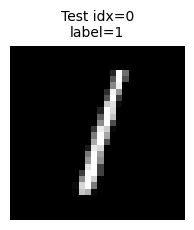

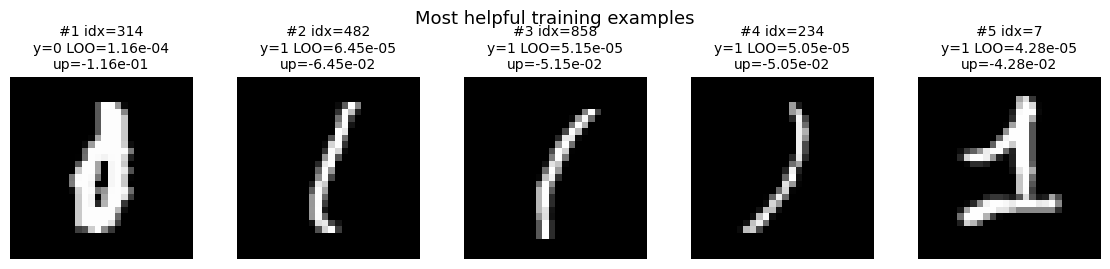

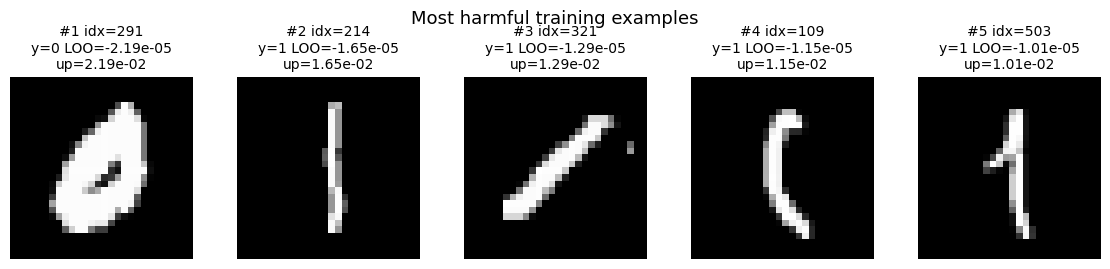

In [5]:
# Visualize the explained test image and the top influence examples.
# Run the previous cells first so data, args, helpful, harmful, up_scores, and loo_scores exist.

import math
import matplotlib.pyplot as plt


def _to_int_indices(indices):
    if hasattr(indices, "detach"):
        indices = indices.detach().cpu().tolist()
    return [int(i) for i in indices]


def _image28(flat_image):
    return flat_image.detach().cpu().reshape(28, 28).numpy()


def _draw_digit(ax, flat_image, title):
    ax.imshow(_image28(flat_image), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


# 1) Show the test image being explained.
test_idx = int(args.test_index)
test_label = int(data.test_y[test_idx].detach().cpu().item())

fig, ax = plt.subplots(figsize=(2.4, 2.4))
_draw_digit(ax, data.test_x[test_idx], f"Test idx={test_idx}\nlabel={test_label}")
plt.tight_layout()
plt.show()


# 2) Show top helpful / harmful training images.
def show_influence_images(indices, title):
    indices = _to_int_indices(indices)
    if len(indices) == 0:
        print(f"No examples to show for {title}.")
        return

    ncols = min(len(indices), 5)
    nrows = math.ceil(len(indices) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.3 * ncols, 2.7 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(indices):]:
        ax.axis("off")

    for rank, (ax, idx) in enumerate(zip(axes, indices), start=1):
        label = int(data.train_y[idx].detach().cpu().item())
        loo = float(loo_scores[idx].detach().cpu().item())
        up = float(up_scores[idx].detach().cpu().item())
        title_text = f"#{rank} idx={idx}\ny={label} LOO={loo:.2e}\nup={up:.2e}"
        _draw_digit(ax, data.train_x[idx], title_text)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_influence_images(helpful, "Most helpful training examples")
show_influence_images(harmful, "Most harmful training examples")
